In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
df = pd.read_csv("dataset.csv")

df.head()

,fever,headache,cough,fatigue,body pain,sore throat,chest pain,shortness of breath,vomiting,diarrhea,...,ear pain,eye redness,blurred vision,palpitations,anxiety,loss of appetite,weight loss,swelling,dry mouth,disease
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
1,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
2,1,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
3,1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu
4,1,0,1,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Flu


In [3]:
print("Dataset shape:", df.shape)
print("\nDisease counts:")
print(df["disease"].value_counts())

Dataset shape: (360, 31)

Disease counts:
disease
Flu                        20
Common Cold                20
COVID-19                   20
Migraine                   20
Food Poisoning             20
Gastritis                  20
Respiratory Issue          20
Allergy                    20
Urinary Tract Infection    20
Joint Inflammation         20
Asthma                     20
Bronchitis                 20
Pneumonia                  20
Eczema                     20
Skin Infection             20
Vertigo                    20
Possible Cardiac Issue     20
Kidney Stone               20
Name: count, dtype: int64


In [4]:
X = df.drop("disease", axis=1)
y = df["disease"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (360, 30)
Target: (360,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (288, 30)
Testing size: (72, 30)


In [ ]:
rf_model = RandomForestClassifier( # Create Random Forest model
    n_estimators=500,  # n_estimators=500 means using 500 decision trees
    random_state=42,
    class_weight="balanced"# class_weight='balanced' helps handle disease distribution fairly
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
y_pred = rf_model.predict(X_test) # Use the trained model to predict diseases

print("Prediction completed.")

Prediction completed.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)# Accuracy: overall prediction correctness
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)# Precision:how accurate positive predictions are
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)# Recall:how many true disease cases were detected
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)# F1-score:balance between precision and recall

print("Random Forest Results")
print("---------------------")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Random Forest Results
---------------------
Accuracy: 0.625
Precision: 0.6269
Recall: 0.625
F1-score: 0.6071


In [ ]:
print(classification_report(y_test, y_pred, zero_division=0))# Display detailed performance metrics

                         precision    recall  f1-score   support

                Allergy       0.75      0.75      0.75         4
                 Asthma       0.00      0.00      0.00         4
             Bronchitis       0.00      0.00      0.00         4
               COVID-19       0.00      0.00      0.00         4
            Common Cold       1.00      0.50      0.67         4
                 Eczema       1.00      1.00      1.00         4
                    Flu       0.60      0.75      0.67         4
         Food Poisoning       1.00      0.75      0.86         4
              Gastritis       0.80      1.00      0.89         4
     Joint Inflammation       1.00      1.00      1.00         4
           Kidney Stone       0.67      1.00      0.80         4
               Migraine       1.00      0.75      0.86         4
              Pneumonia       0.33      0.25      0.29         4
 Possible Cardiac Issue       0.50      0.75      0.60         4
      Respiratory Issue 

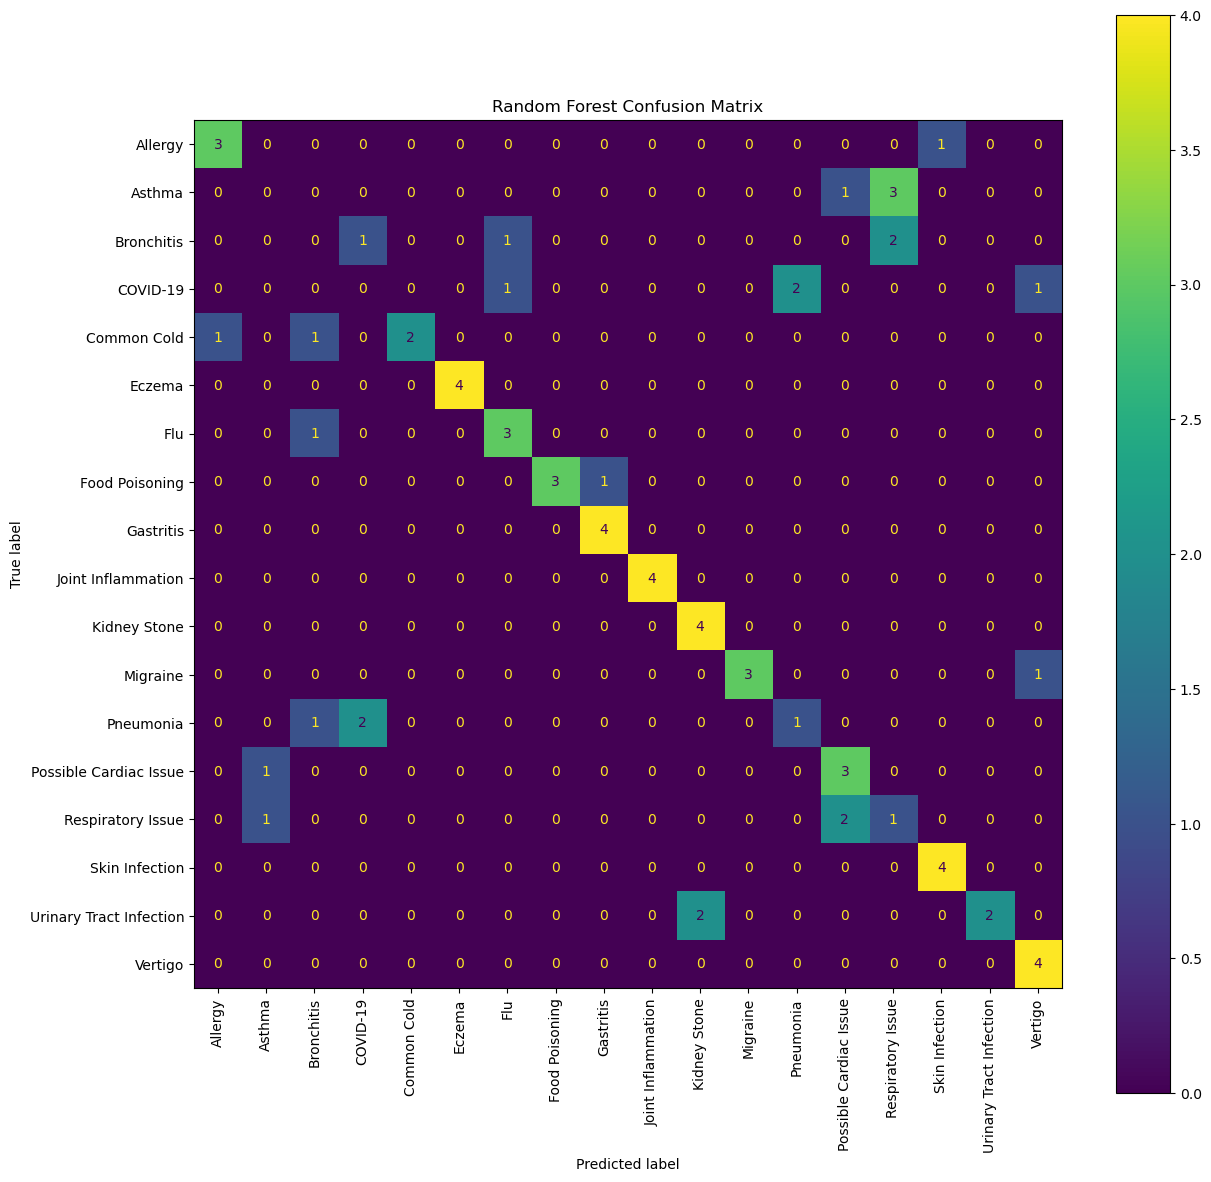

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)# Generate confusion matrix

# Confusion matrix shows:
# correct predictions
# incorrect predictions
# and disease confusion patterns

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [14]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4)
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.625,
 'Precision': 0.6269,
 'Recall': 0.625,
 'F1-score': 0.6071}